# Get Sample Data

In [20]:
import os
os.makedirs("tempfiles", exist_ok=True)
os.makedirs("output", exist_ok=True)

# Set ALEVIN_FRY_HOME environment variable for simpleaf (use absolute path)
alevin_fry_home = os.path.abspath('.')
%env ALEVIN_FRY_HOME=$alevin_fry_home

env: ALEVIN_FRY_HOME=/home/liam/Bioinformatics/fall25-csc-bioinf/week6


In [21]:
!curl -L "https://github.com/f0t1h/3M-february-2018/raw/refs/heads/master/3M-february-2018.txt.gz" -o "tempfiles/3M-february-2018.txt.gz"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 17.5M  100 17.5M    0     0  15.5M      0  0:00:01  0:00:01 --:--:-- 64.3M


In [96]:
!gunzip -f tempfiles/3M-february-2018.txt.gz

gzip: tempfiles/3M-february-2018.txt.gz: No such file or directory


In [97]:
!tar -xf tempfiles/toy_read_ref_set.tar.gz -C tempfiles/

# Install Required Packages

In [98]:
import sys

# Download and install simpleaf
!curl --proto '=https' --tlsv1.2 -LsSf https://github.com/COMBINE-lab/simpleaf/releases/download/v0.19.4/simpleaf-installer.sh | sh
!mv simpleaf-x86_64-unknown-linux-gnu/simpleaf simpleaf 2>/dev/null || true
!chmod +x simpleaf
!./simpleaf --version

downloading simpleaf 0.19.4 x86_64-unknown-linux-gnu
installing to /home/liam/.cargo/bin
  simpleaf
everything's installed!
simpleaf 0.19.4


In [ ]:
# Download and install salmon
!curl -L "https://github.com/COMBINE-lab/salmon/releases/download/v1.10.0/salmon-1.10.0_linux_x86_64.tar.gz" -o salmon.tar.gz
!tar -xzf salmon.tar.gz
!chmod +x salmon-latest_linux_x86_64/bin/salmon

# Download and install alevin-fry (skip if already exists from git)
import os
if not os.path.exists("alevin-fry-x86_64-unknown-linux-gnu/alevin-fry"):
    print("Downloading alevin-fry...")
    !curl -L "https://github.com/COMBINE-lab/alevin-fry/releases/download/v0.11.2/alevin-fry-v0.11.2-x86_64-unknown-linux-gnu.tar.gz" -o alevin-fry.tar.gz
    !tar -xzf alevin-fry.tar.gz
    !chmod +x alevin-fry-x86_64-unknown-linux-gnu/alevin-fry
else:
    print("Using existing alevin-fry binary from git")

# Verify it works
!chmod +x alevin-fry-x86_64-unknown-linux-gnu/alevin-fry

# Add both to PATH for this session
salmon_path = os.path.abspath('salmon-latest_linux_x86_64/bin')
alevin_fry_path = os.path.abspath('alevin-fry-x86_64-unknown-linux-gnu')
os.environ['PATH'] = f"{salmon_path}:{alevin_fry_path}:{os.environ['PATH']}"

# Verify versions
!salmon --version

# Test alevin-fry can actually run (not just exist)
print("\nTesting alevin-fry binary...")
import subprocess
try:
    result = subprocess.run(['./alevin-fry-x86_64-unknown-linux-gnu/alevin-fry', '--version'], 
                          capture_output=True, text=True, timeout=5)
    if result.returncode == 0:
        print(f"✓ alevin-fry working: {result.stdout.strip()}")
    else:
        print(f"✗ alevin-fry failed with exit code {result.returncode}")
        print(f"stderr: {result.stderr}")
        raise RuntimeError("alevin-fry binary test failed")
except FileNotFoundError as e:
    print(f"✗ alevin-fry binary not found: {e}")
    raise
except Exception as e:
    print(f"✗ alevin-fry test failed: {e}")
    print("Checking for missing libraries...")
    !ldd alevin-fry-x86_64-unknown-linux-gnu/alevin-fry
    raise

In [133]:
import scanpy as sc
import pyroe
import celltypist
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Build Reference Index with Simpleaf

In [134]:
!export ALEVIN_FRY_HOME=$(pwd) && export PATH="$(pwd)/salmon-latest_linux_x86_64/bin:$(pwd)/alevin-fry-x86_64-unknown-linux-gnu:$PATH" && ./simpleaf set-paths

2025-11-17T06:41:52.152386Z  INFO simpleaf::utils::prog_utils: could not find piscem executable, so salmon will be required.
found `salmon` in the PATH at /home/liam/Bioinformatics/fall25-csc-bioinf/week6/salmon-latest_linux_x86_64/bin/salmon
found `alevin-fry` in the PATH at /home/liam/Bioinformatics/fall25-csc-bioinf/week6/alevin-fry-x86_64-unknown-linux-gnu/alevin-fry
2025-11-17T06:41:52.171101Z  INFO simpleaf::utils::prog_utils: Could not find macs3 executable, peak calling cannot be peformed by simpleaf


In [135]:
!export ALEVIN_FRY_HOME=$(pwd) && export PATH="$(pwd)/salmon-latest_linux_x86_64/bin:$(pwd)/alevin-fry-x86_64-unknown-linux-gnu:$PATH" && ./simpleaf index \
    --output simpleaf_index \
    --fasta tempfiles/toy_ref_read/toy_human_ref/fasta/genome.fa \
    --gtf tempfiles/toy_ref_read/toy_human_ref/genes/genes.gtf \
    --rlen 91 \
    --threads 2 \
    --no-piscem

2025-11-17T06:41:52.306478Z  INFO simpleaf::simpleaf_commands::indexing: preparing to make reference with roers
2025-11-17T06:41:52.311214Z  INFO grangers::reader::gtf: Finished parsing the input file. Found 3 comments and 2439 records.
2025-11-17T06:41:52.317518Z  INFO roers: Built the Grangers object for 2439 records
2025-11-17T06:41:52.359065Z  WARN grangers::grangers_info: The exon_number column contains null values. Will compute the exon number from exon start position .
2025-11-17T06:41:52.371500Z  INFO roers: Found 2148 exon records from 271 transcripts.
2025-11-17T06:41:52.646631Z  INFO roers: Wrote transcript sequences to output file.
2025-11-17T06:41:52.646907Z  INFO roers: Processing intronic records.
2025-11-17T06:41:52.670382Z  INFO roers: Found 1877 intronic records.
2025-11-17T06:41:52.670424Z  INFO roers: Added flanking length to intronic records.
2025-11-17T06:41:52.675197Z  INFO roers: Merged overlapping intronic records.
2025-11-17T06:41:52.804941Z  INFO roers: Wrote

# Quantify with Alevin-fry

In [ ]:
!export ALEVIN_FRY_HOME=$(pwd) && export PATH="$(pwd)/salmon-latest_linux_x86_64/bin:$(pwd)/alevin-fry-x86_64-unknown-linux-gnu:$PATH" && ./simpleaf quant \
    --reads1 tempfiles/toy_ref_read/toy_read_fastq/selected_R1_reads.fastq \
    --reads2 tempfiles/toy_ref_read/toy_read_fastq/selected_R2_reads.fastq \
    --threads 2 \
    --index simpleaf_index/index \
    --chemistry 10xv3 \
    --resolution cr-like \
    --expected-ori fw \
    --unfiltered-pl tempfiles/3M-february-2018.txt \
    --t2g-map simpleaf_index/index/t2g_3col.tsv \
    --output alevin_output

# Verify quantification succeeded by checking for output files
import os
print("\n=== Verifying alevin-fry output ===")
quant_dir = "alevin_output/af_quant"
required_files = ["quant.json", "meta_info.json"]

# Check directory exists
if not os.path.exists(quant_dir):
    print(f"✗ ERROR: Output directory {quant_dir} does not exist!")
    raise RuntimeError(f"Quantification failed: {quant_dir} not found")

# List all files in output directory
print(f"Files in {quant_dir}:")
!ls -lah alevin_output/af_quant/

# Check for either quant.json or meta_info.json
has_quant = os.path.exists(f"{quant_dir}/quant.json")
has_meta = os.path.exists(f"{quant_dir}/meta_info.json")

if has_quant:
    print(f"✓ Found quant.json")
elif has_meta:
    print(f"✓ Found meta_info.json (older format)")
else:
    print(f"✗ ERROR: Neither quant.json nor meta_info.json found!")
    print("\nDebugging: Running alevin-fry quant manually to see error...")
    !./alevin-fry-x86_64-unknown-linux-gnu/alevin-fry quant \
        -i alevin_output/af_quant \
        -o alevin_output/af_quant_debug \
        -t 2 \
        -m simpleaf_index/index/t2g_3col.tsv \
        -r cr-like
    raise RuntimeError("Quantification failed: no output files generated")

# Load Data into AnnData Object

In [137]:
adata = pyroe.load_fry("alevin_output/af_quant", output_format='scRNA')
print(f"Loaded AnnData with shape: {adata.shape}")

# Convert Ensembl IDs to gene symbols for CellTypist compatibility
# Load the gene ID to gene name mapping
gene_mapping = pd.read_csv("simpleaf_index/ref/gene_id_to_name.tsv", sep="\t", header=None, names=["gene_id", "gene_name"])
gene_mapping = gene_mapping.set_index("gene_id")

# Map the gene IDs to gene names
adata.var["gene_ids"] = adata.var_names  # Keep original IDs
adata.var["gene_names"] = adata.var_names.map(lambda x: gene_mapping.loc[x, "gene_name"] if x in gene_mapping.index else x)
# Use gene symbols as the primary index
adata.var_names = adata.var["gene_names"]
adata.var_names.name = "gene_names"

print(f"Converted gene IDs to symbols. First 5 genes: {list(adata.var_names[:5])}")
adata

USA mode: True
Using pre-defined output format: scrna
Will populate output field X with sum of counts frorm ['S', 'A'].
Will combine ['U'] into output layer unspliced.
Loaded AnnData with shape: (139, 20)
Converted gene IDs to symbols. First 5 genes: ['NDFIP1', 'UBE2D2', 'APC', 'VCAN', 'UBE2B']


AnnData object with n_obs × n_vars = 139 × 20
    obs: 'barcodes'
    var: 'gene_ids', 'gene_names'
    layers: 'unspliced'

# Quality Control and Preprocessing

In [138]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, percent_top=None, log1p=False, inplace=True)

# Filter cells and genes (adjusted for small toy dataset)
# For a toy dataset with only ~20 genes, we use much lower thresholds
sc.pp.filter_cells(adata, min_genes=3)  # Reduced from 200 to 3 for toy data
sc.pp.filter_genes(adata, min_cells=3)

print(f"After filtering: {adata.shape}")

# Normalize total counts per cell
sc.pp.normalize_total(adata, target_sum=1e4)

# Logarithmize the data
sc.pp.log1p(adata)

# For this tiny toy dataset, mark all genes as highly variable
# This ensures that all genes are used in downstream analysis
adata.var['highly_variable'] = True

# Store the log-normalized data for CellTypist (before scaling)
# CellTypist requires log1p normalized expression to 10000 counts per cell
# IMPORTANT: Make a deep copy to preserve the state before scaling
adata.raw = adata.copy()

# Scale the data (will now scale all genes since they're all marked as highly variable)
# Scanpy's scale function handles zero-variance genes by centering them to 0
sc.pp.scale(adata, max_value=10)

After filtering: (132, 19)


In [139]:
# Perform PCA (adjusted for small toy dataset)
# With only ~19 genes, we can only compute a maximum of 18 principal components
n_comps = min(adata.n_vars - 1, 10)  # Use at most 10 PCs or n_genes-1, whichever is smaller
sc.tl.pca(adata, n_comps=n_comps, svd_solver='arpack')

# Compute the neighborhood graph
# Adjust n_pcs to match the number of components we actually computed
n_pcs_to_use = min(n_comps, 10)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs_to_use)

# Compute UMAP
sc.tl.umap(adata)

# Leiden Clustering

In [140]:
# Perform Leiden clustering
sc.tl.leiden(adata, resolution=0.5)

print(f"Number of clusters: {len(adata.obs['leiden'].unique())}")

Number of clusters: 3


# Visualization: Clustering Plot

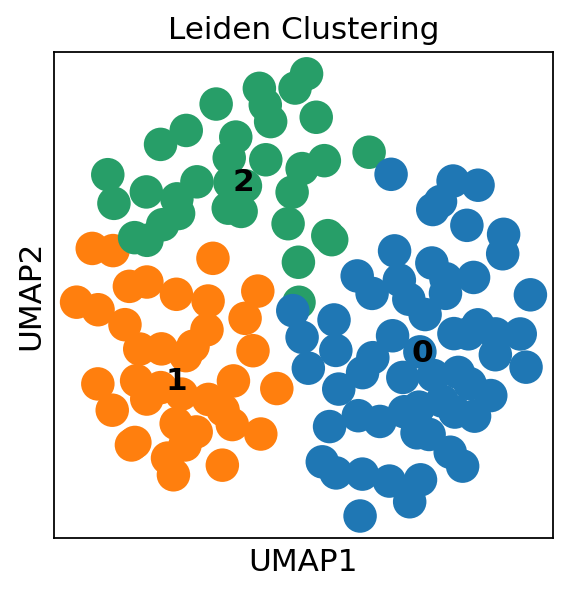

In [141]:
sc.pl.umap(adata, color=['leiden'], legend_loc='on data', title='Leiden Clustering', save='_leiden_clustering.png')
plt.show()

# Cell Type Annotation with CellTypist

In [142]:
# Download and use a pre-trained model
celltypist.models.download_models(force_update=False)

# Show available models
print("Available models:")
print(celltypist.models.models_description())

📂 Storing models in /home/liam/.celltypist/data/models
⏩ Skipping [1/58]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/58]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/58]: Adult_COVID19_PBMC.pkl (file exists)
⏩ Skipping [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/58]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/58]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/58]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/58]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/58]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/58]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/58]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/58]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/58]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/58]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/58]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipping [16/58]: Autopsy_COVID19_Lung.pkl (fil

Available models:
                                      model  \
0                        Immune_All_Low.pkl   
1                       Immune_All_High.pkl   
2                    Adult_COVID19_PBMC.pkl   
3   Adult_CynomolgusMacaque_Hippocampus.pkl   
4                       Adult_Human_MTG.pkl   
5           Adult_Human_PancreaticIslet.pkl   
6          Adult_Human_PrefrontalCortex.pkl   
7                      Adult_Human_Skin.pkl   
8                  Adult_Human_Vascular.pkl   
9                       Adult_Mouse_Gut.pkl   
10            Adult_Mouse_OlfactoryBulb.pkl   
11                Adult_Pig_Hippocampus.pkl   
12      Adult_RhesusMacaque_Hippocampus.pkl   
13                Adult_cHSPCs_Illumina.pkl   
14                  Adult_cHSPCs_Ultima.pkl   
15                 Autopsy_COVID19_Lung.pkl   
16         COVID19_HumanChallenge_Blood.pkl   
17             COVID19_Immune_Landscape.pkl   
18                   Cells_Adult_Breast.pkl   
19                     Cells_Fetal_Lung.pk

In [143]:
# Use the Immune_All_Low model for annotation
# NOTE: This toy dataset has only 19 genes, so results may be limited
# For real datasets with thousands of genes, this would work much better
model = celltypist.models.Model.load(model='Immune_All_Low.pkl')

# Predict cell types
predictions = celltypist.annotate(adata, model='Immune_All_Low.pkl', majority_voting=True)

# Transfer predictions to the original AnnData object
adata.obs['cell_type'] = predictions.predicted_labels.majority_voting
adata.obs['cell_type_predicted'] = predictions.predicted_labels.predicted_labels

print(f"Unique cell types: {adata.obs['cell_type'].unique()}")

👀 Invalid expression matrix in `.X`, expect log1p normalized expression to 10000 counts per cell; will use `.raw.X` instead
🔬 Input data has 132 cells and 19 genes
🔗 Matching reference genes in the model
🧬 10 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 5
🗳️ Majority voting the predictions
✅ Majority voting done!


Unique cell types: ['Epithelial cells', 'Fibroblasts', 'Double-positive thymocytes', 'Tcm/Naive helper T cells']
Categories (4, object): ['Double-positive thymocytes', 'Epithelial cells', 'Fibroblasts', 'Tcm/Naive helper T cells']


# Visualization: Annotated Plot with Cell Types

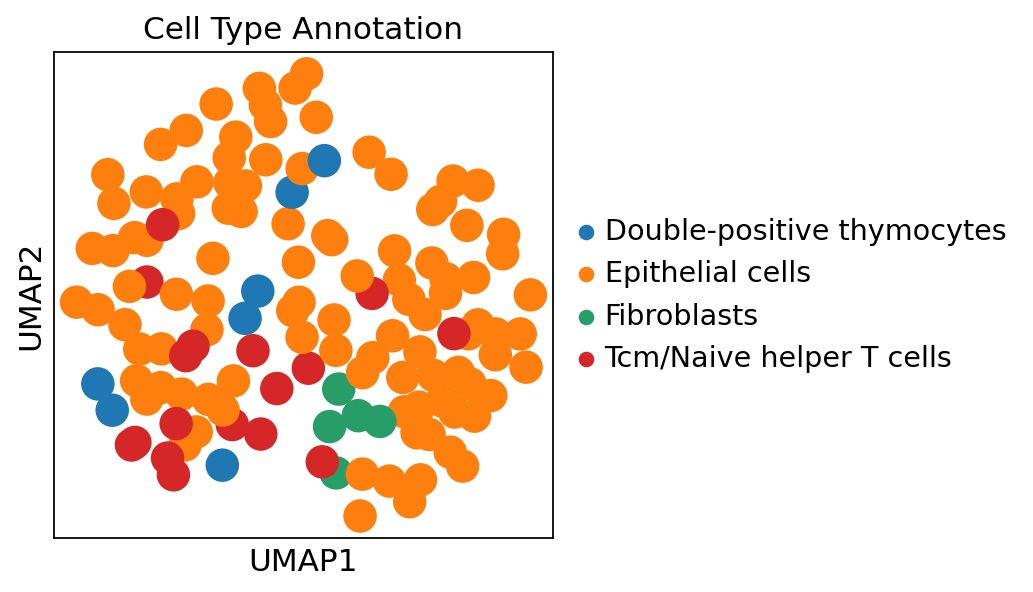

In [144]:
sc.pl.umap(adata, color=['cell_type'], title='Cell Type Annotation', save='_cell_type_annotation.png')
plt.show()

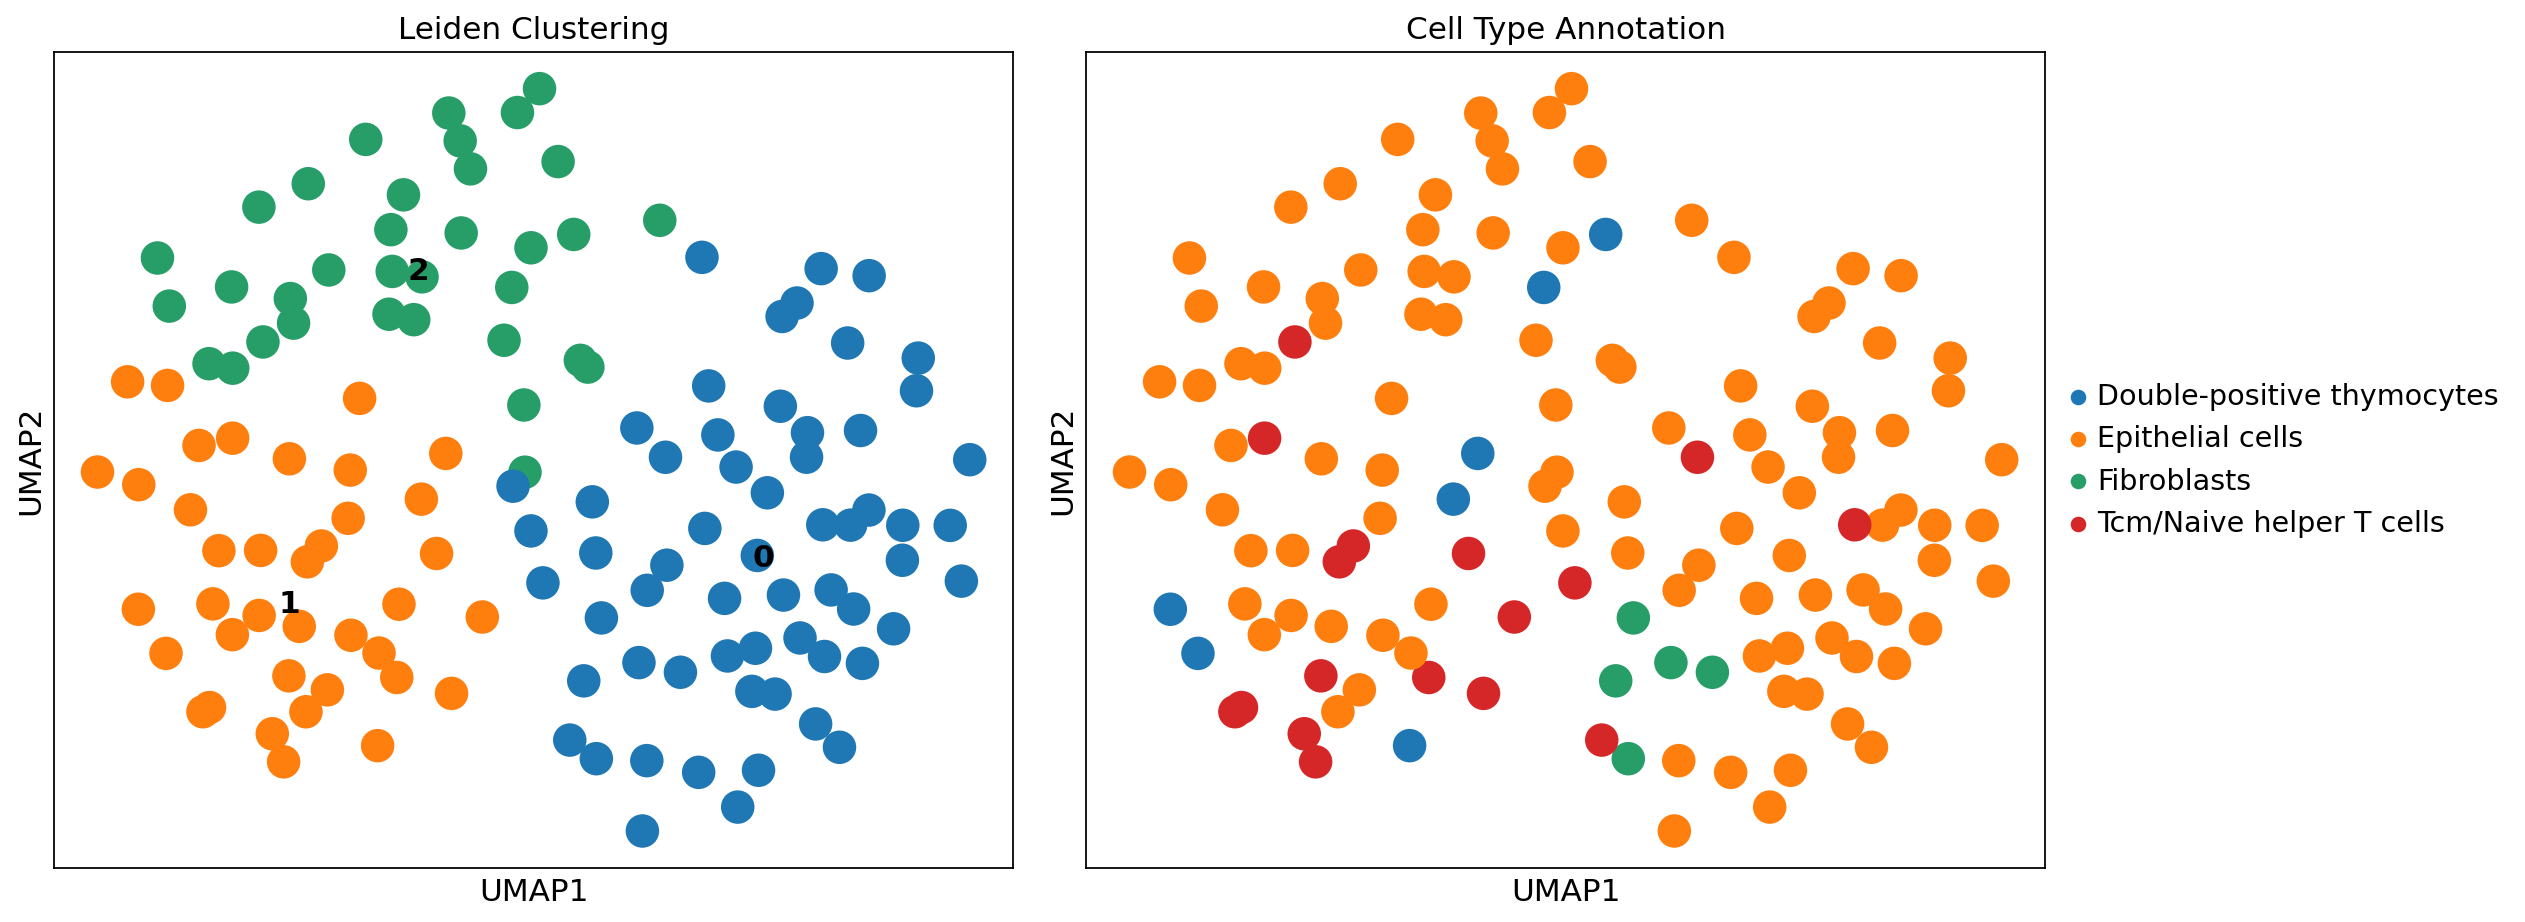

In [145]:
# Also plot both clustering and cell type side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

sc.pl.umap(adata, color=['leiden'], legend_loc='on data', title='Leiden Clustering', ax=ax1, show=False)
sc.pl.umap(adata, color=['cell_type'], title='Cell Type Annotation', ax=ax2, show=False)

plt.tight_layout()
plt.savefig('output/combined_clustering_annotation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary

In [146]:
print("="*60)
print("SINGLE-CELL RNA-SEQ ANALYSIS COMPLETE")
print("="*60)
print(f"\nDataset shape: {adata.shape[0]} cells × {adata.shape[1]} genes")
print(f"Number of Leiden clusters: {len(adata.obs['leiden'].unique())}")
print(f"Number of unique cell types identified: {len(adata.obs['cell_type'].unique())}")
print(f"\nCell type distribution:")
print(adata.obs['cell_type'].value_counts())
print("\n" + "="*60)

SINGLE-CELL RNA-SEQ ANALYSIS COMPLETE

Dataset shape: 132 cells × 19 genes
Number of Leiden clusters: 3
Number of unique cell types identified: 4

Cell type distribution:
cell_type
Epithelial cells              103
Tcm/Naive helper T cells       17
Double-positive thymocytes      7
Fibroblasts                     5
Name: count, dtype: int64

